# 01. 선형 회귀로 기여도 분해하기

## 핵심 아이디어
판매량을 **여러 조각의 합**으로 봅니다.

> "평소라면 900개 팔렸을 텐데, 이번 주엔 프로모션 때문에 +269, 광고 때문에 +135, 더운 날씨 때문에 −68…"

각 조각(요인의 기여도) = **계수(β) × 그 주의 값**이라서, 조각을 모두 더하면 모델 예측치가 됩니다.
이런 구조를 **가법(additive) 모델**이라고 하고, 마케팅 믹스 모델(MMM)의 가장 기본 형태입니다.

In [1]:
import sys, warnings
sys.path.append("../src")
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib  # 한글 글꼴
from common import *
plt.rcParams["figure.dpi"] = 110
df = load_data()
y = df.sellout.values.astype(float)
print(df.shape)

(104, 8)


## 모델 공식

```
셀아웃(t) = β0 + β1·t                          ← 기본 수요 (출발점 + 추세)
          + β2·sin(2πt/52) + β3·cos(2πt/52)   ← 계절성
          + β4·할인율(t)
          + β5·프로모션(t)                     ← 있으면 1, 없으면 0
          + β6·ln(1 + 광고스톡(t))             ← 광고
          + β7·공휴일(t)
          + β8·(기온(t) − 평균기온)
          + β9·결품일수(t)
          + ε(t)                               ← 설명 안 된 부분

광고스톡(t) = 광고비(t) + λ · 광고스톡(t−1)
```

**각 항이 이렇게 생긴 이유**
- **sin + cos**: 52주 주기로 오르내리는 물결. 두 개를 섞으면 성수기가 언제든 맞출 수 있습니다.
- **ln(1 + 광고스톡)**: 광고비가 커질수록 효과가 둔해지는 **포화 효과**.
- **광고스톡**: 이번 주 광고 + 지난주 효과의 λ만큼. 광고가 다음 주까지 이어지는 **이월 효과(adstock)**.
- **기온 − 평균기온**: 평균 기온일 때 효과가 0이 되도록 기준을 맞춤.

**β는 어떻게 찾나?** 실제 판매와 예측의 차이를 제곱해 모두 더한 값이 가장 작아지는 β를 고릅니다(최소제곱법, OLS).
λ는 0.0, 0.1, …, 0.9를 모두 넣어보고 가장 잘 맞는 값을 고릅니다.

In [2]:
def build_X(df, decay):
    t = np.arange(len(df))
    return {
        "trend": t.astype(float),
        "s1": np.sin(2 * np.pi * t / 52), "c1": np.cos(2 * np.pi * t / 52),
        "discount": df.discount_pct.values.astype(float),
        "promo": df.promo.values.astype(float),
        "ad": np.log1p(adstock(df.ad_spend.values, decay)),
        "holiday": df.holiday.values.astype(float),
        "temp": df.temp.values - df.temp.mean(),
        "stockout": df.stockout_days.values.astype(float),
    }

results = []
for decay in np.arange(0, 0.91, 0.1):
    X = build_X(df, decay)
    M = np.column_stack([np.ones(len(y))] + list(X.values()))
    beta, *_ = np.linalg.lstsq(M, y, rcond=None)
    results.append((r2(y, M @ beta), round(decay, 1), X, beta, M @ beta))

for score, decay, *_ in results:
    print(f"이월률 λ={decay:.1f}  R²={score:.4f}")
score, decay, X, beta, pred = max(results, key=lambda r: r[0])
print(f"\n선택: λ={decay}, R²={score:.3f}")

이월률 λ=0.0  R²=0.9428
이월률 λ=0.1  R²=0.9474
이월률 λ=0.2  R²=0.9506
이월률 λ=0.3  R²=0.9536
이월률 λ=0.4  R²=0.9564
이월률 λ=0.5  R²=0.9583
이월률 λ=0.6  R²=0.9591
이월률 λ=0.7  R²=0.9582
이월률 λ=0.8  R²=0.9537
이월률 λ=0.9  R²=0.9397

선택: λ=0.6, R²=0.959


## 학습된 계수 해석

In [3]:
coef = dict(zip(["intercept"] + list(X), beta))
desc = {
    "intercept": "출발점 기본 수요 (개/주)", "trend": "매주 늘어나는 기본 수요", "s1": "계절성 (sin 성분)", "c1": "계절성 (cos 성분)",
    "discount": "할인율 1%p당", "promo": "프로모션 진행 주", "ad": "ln(1+광고스톡) 1단위당",
    "holiday": "공휴일이 낀 주", "temp": "평균보다 1°C 높을 때", "stockout": "결품 하루당",
}
pd.DataFrame({"계수": pd.Series(coef).round(2), "의미": pd.Series(desc)})

,계수,의미
intercept,861.34,출발점 기본 수요 (개/주)
trend,1.25,매주 늘어나는 기본 수요
s1,57.19,계절성 (sin 성분)
c1,-99.81,계절성 (cos 성분)
discount,13.16,할인율 1%p당
promo,268.80,프로모션 진행 주
ad,58.58,ln(1+광고스톡) 1단위당
holiday,167.83,공휴일이 낀 주
temp,-5.39,평균보다 1°C 높을 때
stockout,-91.03,결품 하루당


- 프로모션 주에는 약 **+269개**, 공휴일 주에는 약 **+168개** 더 팔립니다.
- 할인율 1%p당 약 **+13개**, 결품 하루당 약 **−91개**입니다.
- 기온이 평균보다 1°C 높으면 약 **−5개** (이 가상 제품은 추울수록 잘 팔립니다).

## 주별 기여도 = 계수 × 그 주의 값

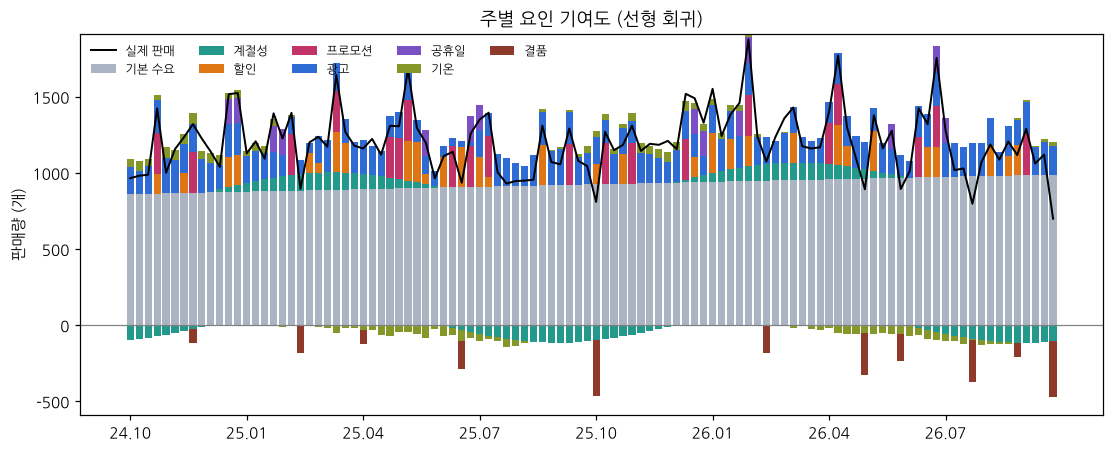

In [4]:
contrib = {
    "기본 수요": coef["intercept"] + coef["trend"] * X["trend"],
    "계절성": coef["s1"] * X["s1"] + coef["c1"] * X["c1"],
    "할인": coef["discount"] * X["discount"],
    "프로모션": coef["promo"] * X["promo"],
    "광고": coef["ad"] * X["ad"],
    "공휴일": coef["holiday"] * X["holiday"],
    "기온": coef["temp"] * X["temp"],
    "결품": coef["stockout"] * X["stockout"],
}
plot_stacked(df, contrib, "주별 요인 기여도 (선형 회귀)");

## 한 주를 분해해서 읽기 (워터폴)

워터폴은 **위에서 아래로** 읽습니다. 기본 수요에서 출발해, 각 요인만큼 오른쪽(판매 증가) 또는 왼쪽(판매 감소)으로 이동하면 마지막에 **모델 예측**에 도달합니다.
맨 아래 **실제 판매**는 모델이 계산한 값이 아니라 실제로 팔린 숫자이고, 둘의 차이가 모델이 설명하지 못한 부분입니다.

{'week': Timestamp('2026-09-28 00:00:00'), 'discount_pct': 0, 'promo': 0, 'ad_spend': 0.0, 'holiday': 0, 'temp': 8.3, 'stockout_days': 4}


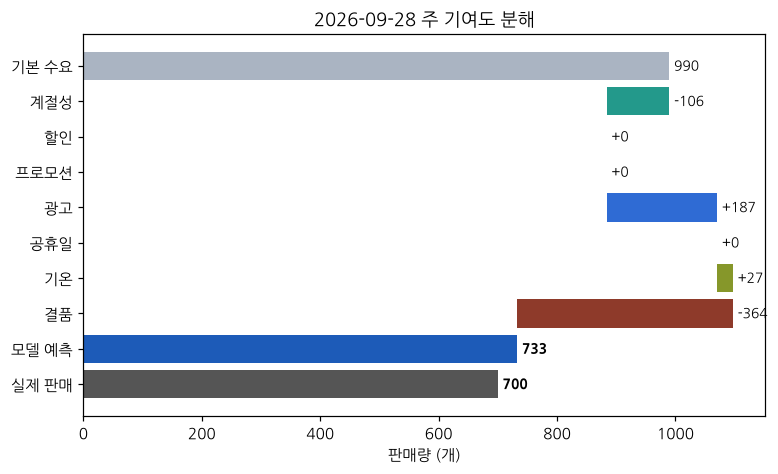

In [5]:
i = len(df) - 1   # 가장 최근 주
print(df.iloc[i][["week", "discount_pct", "promo", "ad_spend", "holiday", "temp", "stockout_days"]].to_dict())
plot_waterfall(contrib, i, actual=y[i], title=f"{df.week[i]:%Y-%m-%d} 주 기여도 분해");

In [6]:
row = {k: contrib[k][i] for k in FACTORS}
base = row["기본 수요"]
print(f"실제 {y[i]:.0f}개 = 기본 수요 {base:.0f}개 + 요인 효과 {sum(row.values()) - base:+.0f}개 + 설명 안 된 부분 {y[i] - pred[i]:+.0f}개")
pos = {k: v for k, v in row.items() if v > 0}
print("\n판매를 끌어올린 힘의 비율 (판매를 올린 요인 합계 = 100%):")
for k, v in sorted(pos.items(), key=lambda kv: -kv[1]):
    print(f"  {k:6s} {v / sum(pos.values()) * 100:5.1f}%")
neg = {k: v for k, v in row.items() if v < -0.5}
if neg:
    print("판매를 줄인 요인:", {k: round(v) for k, v in neg.items()})

실제 700개 = 기본 수요 990개 + 요인 효과 -257개 + 설명 안 된 부분 -33개

판매를 끌어올린 힘의 비율 (판매를 올린 요인 합계 = 100%):
  기본 수요   82.3%
  광고      15.5%
  기온       2.2%
판매를 줄인 요인: {'계절성': -106, '결품': -364}


**실무 해석 예시** (2025-04-28 주: 프로모션 진행, 기온 25.8°C, 실제 1,310개)
"이번 주 프로모션이 없었다면 약 1,040개 수준이었을 것이다. 프로모션으로 약 270개, 광고로 약 135개를 더 팔았다. 더운 날씨가 아니었다면 70개 정도 더 팔 수 있었다."

> 비율 막대는 **판매를 올린 요인들의 합**을 100%로 본 것이라, 판매를 줄인 요인(위 예시의 기온)은 비율에 포함되지 않습니다.

## 모델 성능 지표
- **R²(설명력)**: 판매 변동 중 모델이 설명한 비율. 0.96이면 96%.
- **MAPE(평균 오차율)**: 예측이 실제와 평균적으로 몇 % 차이 나는지.

In [7]:
print(f"R² = {r2(y, pred):.3f},  MAPE = {mape(y, pred):.1f}%")
effects_table({"선형 회귀": effects(contrib, df)}, df)

R² = 0.959,  MAPE = 2.8%


,정답,선형 회귀
할인,14.0,13.2
프로모션,260.0,268.8
광고,52.9,53.9
공휴일,180.0,167.8
기온,-6.0,-5.4
결품,-95.0,-91.0
계절성,120.0,114.9
평균 오차율(%),NaN,5.2


## 주의할 점
- **상관 ≠ 인과**: 프로모션을 성수기에만 했다면 계절 효과가 프로모션 효과로 섞여 과대평가될 수 있습니다.
- **같이 움직이는 요인**: 광고와 프로모션을 항상 같이 했다면 둘의 효과를 분리할 수 없습니다.
- **데이터 양**: 104주면 요인 5~10개가 현실적 한계입니다(README 참고).
- **결품은 꼭 넣기**: 빠뜨리면 "이 주는 인기가 없었다"고 잘못 해석합니다.

이 분석의 HTML 대시보드: `dashboards/01_contribution_decomposition.html`